# Analysis Involving Multiple Tracers

In [1]:
import ISOSIMpy.model as ism
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

## 1. Load (Synthetic) Observation Data
See Example 5 on how this data is generated.

In [2]:
# load input series
# this would be the tracer concentration in precipitation or recharge in a
# practical problem
file_name = "example_input_series_2tracer.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float, float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y-%m") for row in data])
input_series = np.array([[row[1], row[2]] for row in data], dtype=float)

# load observation series
# this would be the measured tracer concentration in groudnwater in a
# practical problem
file_name = "example_observation_series_2tracer.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float, float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y-%m") for row in data])
obs_series = np.array([[row[1], row[2]] for row in data], dtype=float)

# load full system output series
# this would be the true tracer concentration in groudnwater in a practical
# problem; this is not available in practice
file_name = "example_output_series_2tracer.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float, float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y-%m") for row in data])
output_series = np.array([[row[1], row[2]] for row in data], dtype=float)

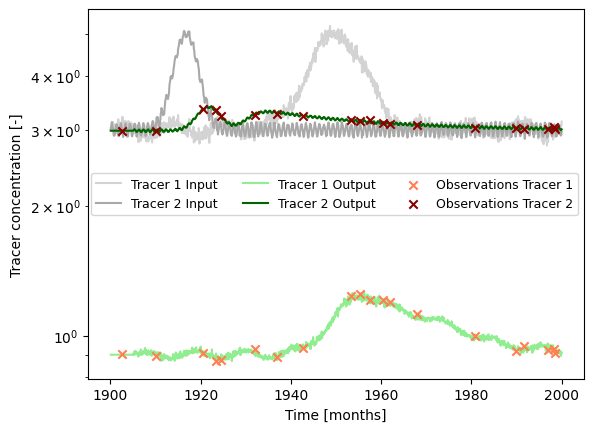

In [3]:
### plot input series, output series, and observations

# get observation timesteps
timesteps = [t.year + t.month / 12.0 for t in timestamps]

# create figure
fig, ax = plt.subplots(1, 1)
# plot input series
ax.plot(
    timesteps,
    input_series[:, 0],
    label="Tracer 1 Input",
    c="lightgrey"
)
ax.plot(
    timesteps,
    input_series[:, 1],
    label="Tracer 2 Input",
    c="darkgrey"
)

# plot output series
ax.plot(
    timesteps,
    output_series[:, 0],
    label="Tracer 1 Output",
    c="lightgreen"
)
ax.plot(
    timesteps,
    output_series[:, 1],
    label="Tracer 2 Output",
    c="darkgreen"
)

# plot observations
ax.scatter(
    timesteps,
    obs_series[:, 0],
    label="Observations Tracer 1",
    color="coral",
    marker="x",
    zorder=10
)
ax.scatter(
    timesteps,
    obs_series[:, 1],
    label="Observations Tracer 2",
    color="darkred",
    marker="x",
    zorder=10
)

ax.set_xlabel("Time [months]")
ax.set_ylabel("Tracer concentration [-]")
ax.legend(ncol=3, fontsize=9)
ax.set_yscale("log")
plt.show()

## 2. Model Setup

In [13]:
t_half = 12.3 * 12.0
lambda_1 = np.log(2.0) / t_half

t_half = 5700. * 12.0
lambda_2 = np.log(2.0) / t_half

### define model (we do not use the same structure / units as the true model)
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=[lambda_1, lambda_2],
    input_series=input_series,
    target_series=obs_series,
    steady_state_input=[3., 3.], # this is the true value
    n_warmup_half_lives=10
)

# add an exponential-piston-flow unit
# define the initial model parameters for inference
epm_mtt_init = 12 * 40 # 20 years
epm_eta_init = 1.5
m.add_unit(
    ism.EPMUnit(mtt=epm_mtt_init, eta=epm_eta_init),
    fraction=1., # true value would be 0.8 (with 0.2 PM)
    bounds=[(1.0, 12.0 * 100.), (1.0, 3.0)],
    prefix="epm"
)

## 3. Model Simulation for Different Mean Travel Times

In [14]:
# Define range of mean travel times to consider
mtt_range = np.linspace(12 * 30, 12 * 50, 10)

# Create empty array of results
results = np.zeros((2, len(mtt_range), len(input_series)))

# Iterate over mean travel times
for i, mtt in enumerate(mtt_range):
    m.set_param(key="epm.mtt", value=mtt)
    sim = m.simulate()
    results[0, i, :] = sim[:, 0].flatten()
    results[1, i, :] = sim[:, 1].flatten()


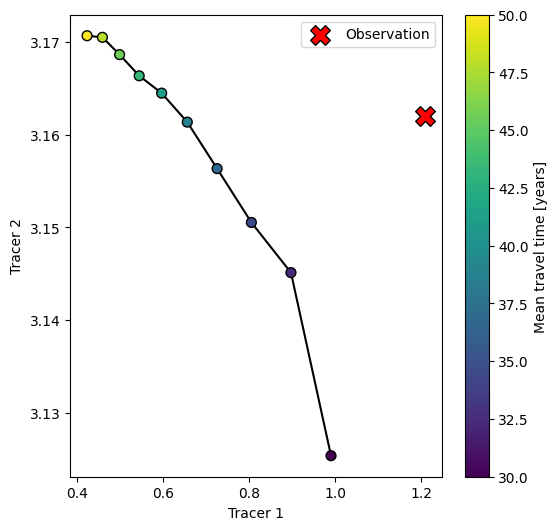

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Get indices of time series that have observations
obs_indices = np.arange(len(timestamps))[~np.isnan(obs_series).any(axis=1)]

idx_select = 10

ax.plot(
    results[0, :, obs_indices[idx_select]],
    results[1, :, obs_indices[idx_select]],
    c="black",
)
im = ax.scatter(
    results[0, :, obs_indices[idx_select]],
    results[1, :, obs_indices[idx_select]],
    c=mtt_range / 12.,
    edgecolor="k",
    s=50,
    zorder=10
)
ax.scatter(
    obs_series[obs_indices[idx_select], 0],
    obs_series[obs_indices[idx_select], 1],
    c="r",
    edgecolor="k",
    marker="X",
    zorder=10,
    s=200,
    label="Observation"
)
plt.colorbar(im, ax=ax, label="Mean travel time [years]")
ax.set_xlabel("Tracer 1")
ax.set_ylabel("Tracer 2")
ax.legend()
plt.show()